In [1]:
import pandas as pd
import pysam
import os
import json
import collections

In [2]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:

    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    if sample in ['NA12884', 'NA12883']:
        continue
    else:
        phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [5]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


## Read in MEI Callset

In [6]:
filledElementDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/MEIs/non-LTR_retrotransposons_GroupFilled.09182025.csv")
filledElementDF['start']=[x.split(":")[1].split("-")[0] for x in filledElementDF['ID']]
filledElementDF['end']=[x.split(":")[1].split("-")[1] for x in filledElementDF['ID']]
filledElementDF['contig']=[x.split(":")[0] for x in filledElementDF['ID']]
filledElementDF['MainElement']=['-'.join(x.split("-")[:2]) for x in filledElementDF['AlignmentGrouping']]

filledElementDF["Haplogroup"] = [
    haplogroups.get(x.split("_")[0], "NONE")
    for x in filledElementDF["ID"]
]
filledElementDF["BroadHaplogroup"] = [
    haplogroups.get(x.split("_")[0], "NONE")[:2]
    for x in filledElementDF["ID"]
]
filledElementDF["Contig"] = [
    x.split(":")[0]
    for x in filledElementDF["ID"]
]
filledElementDF["Sample"] = [
    x.split("_")[0]
    for x in filledElementDF["ID"]
]

In [7]:
filledElementDF2 = filledElementDF[~filledElementDF['Element_Annotation'].str.contains("AluJ|AluS|L1MA7|L1MC1|L1P1")].copy()

In [8]:
badElements=[]
for element in set(filledElementDF2['MainElement']):
    tempDF = filledElementDF2[filledElementDF2['MainElement']==element].copy()
    elementDict = collections.Counter(tempDF['Contig'])
    if max(elementDict.values()) >=2:
        badElements.append(element)

filledElementDF3 = filledElementDF2[~filledElementDF2['MainElement'].isin(badElements)].copy()

In [9]:
filledElementDF4 = filledElementDF3[~filledElementDF3['Sample'].isin(['HG03456', 'NA12884', 'NA12883'])].copy()
filledElementDF4.at[23158,'MainElement']='Alu-410'
filledElementDF5 = filledElementDF4[~filledElementDF4['Contig'].str.contains("random")].copy()

In [10]:
import collections
elementDict = collections.Counter(filledElementDF5['MainElement'])
print(len(collections.Counter(filledElementDF5['MainElement'])))

401


In [11]:
import dendropy

tree = dendropy.Tree.get(
    path="/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex",
    schema="nexus",
    preserve_underscores=True
)

for node in tree.preorder_node_iter():
    label = node.taxon.label if node.taxon else "internal"

In [12]:
import pandas as pd
import numpy as np

def deepest_shared_haplogroup_branch(haplogroups_list, return_mixed_roots=True):
    """
    Infer the deepest shared haplogroup branch from haplogroup strings.

    Examples
    --------
    ['E1a2a1', 'E1a2a1a2', 'E1a2b1a1a1'] -> 'E1a2'
    ['A1a', 'B2a1a1a1', 'B3'] -> 'A|B'
    """
    hgs = [str(h).strip() for h in haplogroups_list if pd.notna(h) and str(h).strip() != ""]
    if not hgs:
        return np.nan

    hgs = list(dict.fromkeys(hgs))

    prefix = hgs[0]
    for h in hgs[1:]:
        while not h.startswith(prefix) and prefix:
            prefix = prefix[:-1]

    if prefix:
        return prefix

    if return_mixed_roots:
        roots = sorted(set(h[0] for h in hgs if len(h) > 0))
        return "|".join(roots) if roots else np.nan

    return np.nan


def infer_element_insertion_intervals(
    nonFixedElements,
    phylogeneticOrder,
    haplogroups,
    element_col="element_id",
    sample_col="sample"
):
    """
    For each element:
      - collect carrier samples
      - find the minimal interval in phylogeneticOrder spanning carriers
      - infer the deepest shared haplogroup branch from carrier haplogroups
      - if ambiguous (mixed roots like 'A|B'), fall back to the first sample
        in phylogenetic order

    Returns
    -------
    pandas.DataFrame
    """
    order_index = {sample: i for i, sample in enumerate(phylogeneticOrder)}
    order_set = set(order_index.keys())

    df = nonFixedElements.copy()

    df = df[df[sample_col].isin(order_set)].copy()

    results = []

    for element, subdf in df.groupby(element_col):
        carriers = sorted(set(subdf[sample_col]))

        if len(carriers) == 0:
            continue

        carrier_positions = sorted(order_index[s] for s in carriers)
        left = min(carrier_positions)
        right = max(carrier_positions)

        span_samples = list(phylogeneticOrder[left:right + 1])
        missing_within_span = [s for s in span_samples if s not in carriers]

        first_sample = phylogeneticOrder[left]
        last_sample = phylogeneticOrder[right]

        carrier_hgs_full = [haplogroups.get(s, np.nan) for s in carriers]
        carrier_hgs = sorted({h for h in carrier_hgs_full if pd.notna(h)})

        shared_branch = deepest_shared_haplogroup_branch(carrier_hgs_full)

        if isinstance(shared_branch, str) and "|" in shared_branch:
            inferred_sample = first_sample
            inferred_hg = haplogroups.get(first_sample, np.nan)
            inference_type = "fallback_first_sample"
        else:
            inferred_sample = first_sample
            inferred_hg = shared_branch
            inference_type = "haplogroup_branch"

        results.append({
            "element_id": element,
            "n_carriers": len(carriers),
            "carrier_samples": carriers,
            "carrier_haplogroups": carrier_hgs,
            "deepest_shared_haplogroup_branch": shared_branch,
            "inferred_insertion_sample": inferred_sample,
            "inferred_insertion_haplogroup": inferred_hg,
            "inference_type": inference_type,
            "left_idx": left,
            "right_idx": right,
            "span_size": len(span_samples),
            "span_samples": span_samples,
            "first_sample": first_sample,
            "last_sample": last_sample,
            "missing_within_span": missing_within_span,
            "n_missing_within_span": len(missing_within_span),
            "is_contiguous_clade_like": len(missing_within_span) == 0,
            "clade_consistency_score": len(carriers) / len(span_samples)
        })

    result_df = pd.DataFrame(results)

    if len(result_df) > 0:
        result_df = result_df.sort_values(
            ["is_contiguous_clade_like", "clade_consistency_score", "n_carriers"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return result_df

In [13]:
elementTreeDF = infer_element_insertion_intervals(
    nonFixedElements=filledElementDF5,
    phylogeneticOrder=phylogeneticOrder,
    haplogroups=haplogroups,
    element_col="MainElement",
    sample_col="Sample"
)

In [14]:
import numpy as np

tree.calc_node_ages()

elementTreeDF['Age'] = np.nan

taxa = tree.taxon_namespace

for row in elementTreeDF.index:

    s1 = elementTreeDF.at[row, 'first_sample']
    s2 = elementTreeDF.at[row, 'last_sample']

    label1 = s1
    label2 = s2

    t1 = taxa.get_taxon(label=label1)
    t2 = taxa.get_taxon(label=label2)

    # safety check
    if t1 is None or t2 is None:
        elementTreeDF.at[row, 'Age'] = np.nan
        continue

    mrca = tree.mrca(taxa=[t1, t2])

    elementTreeDF.at[row, 'Age'] = (mrca.age)*1000000

In [15]:
NeedChecking=[]
subsetMixedElemnts = elementTreeDF[(elementTreeDF['n_carriers']<=100) & (elementTreeDF['Age']==184292.0)].copy()
for row in subsetMixedElemnts.index:
    groupSet = subsetMixedElemnts.at[row,'deepest_shared_haplogroup_branch']
    if len(groupSet.split("|"))>2:
        continue
    else:
        NeedChecking.append(row)
needCheckingDF = subsetMixedElemnts.loc[NeedChecking].copy()
splitElements = [x for x in needCheckingDF['element_id']]

In [16]:
for elementID in splitElements:
    tempDF = filledElementDF5[filledElementDF5['MainElement']==elementID].copy()
    for row in tempDF.index:
        if 'A' in tempDF.at[row,'BroadHaplogroup']:
            continue
        else:
            elementType, elementNAME = tempDF.at[row,'MainElement'].split("-")
            print(elementType, elementNAME)
            filledElementDF5.at[row,'MainElement'] = str(elementType)+"-"+str(int(elementNAME)+10000)

Alu 217
Alu 217
Alu 217
Alu 480
Alu 480
Alu 480
Alu 100
Alu 100
Alu 385
L1 50


In [17]:
tempDict={}
for element in set(filledElementDF5['MainElement']):
    tempDF2 = filledElementDF5[filledElementDF5['MainElement']==element].copy()
    tempDict[element]=np.mean(tempDF2['Element_Divergence'])

In [18]:
badElementsDivs = []
for keyID, divergence in tempDict.items():
    if 'Alu' in keyID and divergence>=5.0:
        badElementsDivs.append(keyID)
    else:
        continue

In [19]:
filledElementDF6 = filledElementDF5[~filledElementDF5['MainElement'].isin(badElementsDivs)].copy()

In [20]:
elementTreeDF = infer_element_insertion_intervals(
    nonFixedElements=filledElementDF6,
    phylogeneticOrder=phylogeneticOrder,
    haplogroups=haplogroups,
    element_col="MainElement",
    sample_col="Sample"
)
import numpy as np

tree.calc_node_ages()

elementTreeDF['Age'] = np.nan

taxa = tree.taxon_namespace

for row in elementTreeDF.index:

    s1 = elementTreeDF.at[row, 'first_sample']
    s2 = elementTreeDF.at[row, 'last_sample']

    label1 = s1
    label2 = s2

    t1 = taxa.get_taxon(label=label1)
    t2 = taxa.get_taxon(label=label2)

    # safety check
    if t1 is None or t2 is None:
        elementTreeDF.at[row, 'Age'] = np.nan
        continue

    mrca = tree.mrca(taxa=[t1, t2])

    elementTreeDF.at[row, 'Age'] = (mrca.age)*1000000

In [22]:
badRows=[x for x in elementTreeDF[(elementTreeDF['n_carriers']>100) & (elementTreeDF['Age']==184292.0)].index]
goodRows=[x for x in elementTreeDF.index if x not in badRows]
checkDF = elementTreeDF.loc[goodRows].copy()
haplogroupsFound = collections.Counter(checkDF['deepest_shared_haplogroup_branch'])
badHaplogroups = []
for x in haplogroupsFound:
    if 'A' in x and 'R' in x:
        badHaplogroups.append(x)
print(badHaplogroups)
fixedElements = [x for x in elementTreeDF[(elementTreeDF['span_size']>100) & (elementTreeDF['Age']==184292.0)]['element_id']]

for eID in elementTreeDF[(elementTreeDF['deepest_shared_haplogroup_branch'].isin(badHaplogroups))]['element_id']:
    if str(eID) in fixedElements:
        continue
    else:
        fixedElements.append(eID)

print(len(fixedElements))

185


In [17]:
#I am leaving the variable name as hg38 since I am lazy
hg38bed = pd.read_csv('/LeeLab/HPRC/chromosomeY/Information/T2Tregions.bed.csv')

#Main umbrella regions of the Y
mainSet = list(hg38bed['name'])

In [24]:
import pandas as pd
import numpy as np

all_results = []

main_name_set = set(mainSet)

for sample in set(filledElementDF6['Sample']):
    tempDF = filledElementDF6[filledElementDF6['Sample'] == sample].copy()

    bed_path = f"/LeeLab/HPRC/chromosomeY/Information/2026-02_final-rev/t2tv2/{sample}.t2tv2.chrY-regions.ngaps.err-struct-base.bed"
    bedFile1 = pd.read_csv(bed_path, sep='\t')
    bedFile1.columns = [c.lstrip("#") for c in bedFile1.columns]

    contig_col = "contig"
    start_col = "start"
    end_col = "end"

    bedFile1["start"] = pd.to_numeric(bedFile1["start"], errors="coerce")
    bedFile1["end"] = pd.to_numeric(bedFile1["end"], errors="coerce")
    tempDF[start_col] = pd.to_numeric(tempDF[start_col], errors="coerce")
    tempDF[end_col] = pd.to_numeric(tempDF[end_col], errors="coerce")

    bedFile1 = bedFile1.dropna(subset=["start", "end"]).copy()

    cenDF = bedFile1[bedFile1["name"].astype(str).str.contains("CEN", na=False)].copy()
    if len(cenDF) == 0:
        cen_mid = None
    else:
        cen_mid = (cenDF["start"].min() + cenDF["end"].max()) / 2

    hetDF = bedFile1[bedFile1["name"].astype(str).str.contains("^HET$", na=False)].copy()
    if len(hetDF) == 0:
        het_start = None
        het_end = None
    else:
        het_start = hetDF["start"].min()
        het_end = hetDF["end"].max()


    bedFile1["resolved_name"] = bedFile1["name"].astype(str)

    def resolve_region_name(row, cen_mid, het_start, het_end):
        name = str(row["name"])
        mid = (row["start"] + row["end"]) / 2

        if name in {"SAT1", "SAT2", "OTHER1", "OTHER2"}:
            return name
            
        if name == "SAT":
            if cen_mid is None:
                return "SAT"
            return "SAT1" if mid < cen_mid else "SAT2"

        if name == "OTHER":
            if het_start is None or het_end is None:
                return "OTHER"

            if mid < het_start:
                return "OTHER1"
            elif mid > het_end:
                return "OTHER2"
            else:
                return "OTHER"

        return name

    bedFile1["resolved_name"] = bedFile1.apply(
        resolve_region_name,
        axis=1,
        cen_mid=cen_mid,
        het_start=het_start,
        het_end=het_end
    )

    bedFile = bedFile1[bedFile1["resolved_name"].isin(main_name_set)].copy()

    best_hits = []
    best_overlap_bp = []
    closest_distance_bp = []

    for idx in tempDF.index:
        my_contig = tempDF.at[idx, contig_col]
        my_start = tempDF.at[idx, start_col]
        my_end = tempDF.at[idx, end_col]

        if pd.isna(my_start) or pd.isna(my_end):
            best_hits.append(None)
            best_overlap_bp.append(np.nan)
            closest_distance_bp.append(np.nan)
            continue

        contig_bed = bedFile[
            (bedFile["seq"] == my_contig) &
            (bedFile["resolved_name"].isin(main_name_set))
        ].copy()

        if len(contig_bed) == 0:
            best_hits.append(None)
            best_overlap_bp.append(0)
            closest_distance_bp.append(np.nan)
            continue


        hits = contig_bed[
            (contig_bed["start"] < my_end) &
            (contig_bed["end"] > my_start)
        ].copy()

        if len(hits) > 0:
            hits["overlap_len"] = (
                np.minimum(hits["end"].to_numpy(), my_end) -
                np.maximum(hits["start"].to_numpy(), my_start)
            )

            hits = hits[hits["overlap_len"] > 0].copy()

            if len(hits) > 0:
                overlap_by_name = (
                    hits.groupby("resolved_name", as_index=False)["overlap_len"]
                    .sum()
                    .sort_values(["overlap_len", "resolved_name"], ascending=[False, True])
                    .reset_index(drop=True)
                )

                best_name = str(overlap_by_name.at[0, "resolved_name"])
                best_bp = overlap_by_name.at[0, "overlap_len"]
                best_dist = 0

                best_hits.append(best_name)
                best_overlap_bp.append(best_bp)
                closest_distance_bp.append(best_dist)
                continue

        contig_bed["distance_bp"] = np.where(
            contig_bed["end"] < my_start,
            my_start - contig_bed["end"],
            np.where(
                contig_bed["start"] > my_end,
                contig_bed["start"] - my_end,
                0
            )
        )

        closest_by_name = (
            contig_bed.groupby("resolved_name", as_index=False)["distance_bp"]
            .min()
            .sort_values(["distance_bp", "resolved_name"], ascending=[True, True])
            .reset_index(drop=True)
        )

        best_name = str(closest_by_name.at[0, "resolved_name"])
        best_bp = 0
        best_dist = closest_by_name.at[0, "distance_bp"]

        best_hits.append(best_name)
        best_overlap_bp.append(best_bp)
        closest_distance_bp.append(best_dist)

    tempDF["overlap_name"] = best_hits
    tempDF["overlap_name_string"] = tempDF["overlap_name"]
    tempDF["overlap_bp"] = best_overlap_bp
    tempDF["closest_distance_bp"] = closest_distance_bp

    all_results.append(tempDF)

finalDF1 = pd.concat(all_results, ignore_index=True)
finalDF = finalDF1[finalDF1["MainElement"] != "L1-16|L1-103|L1-32|Alu-135"].copy()

## MAP THE REMAINING TO CHECK FOR DUPLICATIONS

In [26]:
#for sample in set(finalDF['Sample']):
#    with open('/LeeLab/HPRC/chromosomeY/Data/MEIs/blat/'+str(sample)+"_sequences.fasta", 'a+') as file:
#        finalDF2 = finalDF[finalDF['Sample']==sample].copy()
#        for row in finalDF2.index:
#            contig, coords = finalDF2.at[row,'ID'].split(":")
#            coordStart = int(coords.split("-")[0])-500
#            coordEnd = int(coords.split("-")[1])+500
#            newCoordinate = contig+":"+str(coordStart)+"-"+str(coordEnd)
##            #print(pysam.faidx(assemblyDict[sample], newCoordinate))
#            sequence = ''.join((pysam.faidx(assemblyDict[sample], newCoordinate)).split()[1:])
#            sequenceID= str(finalDF2.at[row,'ID'])#

#            file.write('>'+str(sequenceID)+'\n')
#            file.write(sequence+'\n')
#    file.close()

In [25]:
import subprocess
from pathlib import Path

def run_minimap2_one_sample(
    sample,
    assembly_fa,
    query_fa,
    out_dir,
    env_name=None,
    minimap2_path="minimap2",
    preset="asm5",
    write_cigar=True
):
    assembly_fa = Path(assembly_fa)
    query_fa = Path(query_fa)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_paf = out_dir / f"{sample}.paf"

    if env_name is not None:
        cmd = ["conda", "run", "-n", env_name, minimap2_path]
    else:
        cmd = [minimap2_path]

    if write_cigar:
        cmd += ["-c"]

    cmd += ["-x", preset, str(assembly_fa), str(query_fa)]

    with open(out_paf, "w") as fout:
        result = subprocess.run(cmd, stdout=fout, stderr=subprocess.PIPE, text=True)

    if result.returncode != 0:
        raise RuntimeError(
            f"minimap2 failed for {sample}\nCommand: {' '.join(cmd)}\nError:\n{result.stderr}"
        )

    return str(out_paf)

In [26]:
#query_files={}
#directory = '/LeeLab/HPRC/chromosomeY/Data/MEIs/minimap2_seqs/'
#for sample in os.listdir(directory):
#    query_files[sample.split("_")[0]]=directory+sample
#print(len(query_files))

In [27]:
#assembly_files = assemblyDict.copy()
#for sample in query_files:
#    paf_file = run_minimap2_one_sample(
#        sample=sample,
#        assembly_fa=assembly_files[sample],
#        query_fa=query_files[sample],
#        out_dir="/LeeLab/HPRC/chromosomeY/Data/MEIs/minimap2_results/",
#        env_name=None,   # or None if already in the active env
#        preset="asm5",
#        write_cigar=True
#    )
#    print(sample, paf_file)

In [28]:
import os
import re
import pandas as pd

PAF_COLS = [
    "qname", "qlen", "qstart", "qend", "strand",
    "tname", "tlen", "tstart", "tend",
    "nmatch", "alen", "mapq"
]

coord_pattern = re.compile(r"^(.+):(\d+)-(\d+)$")

def parse_query_coord(qname):
    """
    Parse contig:start-end from query name.
    Returns (contig, start, end) or (None, None, None) if malformed.
    """
    m = coord_pattern.match(str(qname))
    if m is None:
        return None, None, None
    contig, start, end = m.groups()
    return contig, int(start), int(end)

def read_paf(paf_file):
    """
    Read first 12 standard PAF columns.
    """
    df = pd.read_csv(paf_file, sep="\t", header=None, comment="#")
    if df.empty:
        return pd.DataFrame(columns=PAF_COLS)

    df = df.iloc[:, :12].copy()
    df.columns = PAF_COLS

    numeric_cols = ["qlen", "qstart", "qend", "tlen", "tstart", "tend", "nmatch", "alen", "mapq"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

def annotate_paf_with_query_coords(df):
    """
    Add original query contig/start/end from qname.
    """
    parsed = df["qname"].apply(parse_query_coord)
    df[["orig_contig", "orig_start", "orig_end"]] = pd.DataFrame(parsed.tolist(), index=df.index)
    return df

def add_alignment_metrics(df):
    """
    Add percent identity, query coverage, and target span.
    """
    df = df.copy()
    df["pct_identity"] = 100 * df["nmatch"] / df["alen"]
    df["query_cov"] = 100 * (df["qend"] - df["qstart"]) / df["qlen"]
    df["target_span"] = df["tend"] - df["tstart"]
    return df

def is_same_coordinate_hit(row, buffer_bp=0, require_same_contig=True):
    """
    Returns True if target hit overlaps the original query locus.
    buffer_bp expands the original interval when deciding overlap.
    """
    if pd.isna(row["orig_start"]) or pd.isna(row["orig_end"]):
        return False

    same_contig = (row["tname"] == row["orig_contig"])
    if require_same_contig and not same_contig:
        return False

    orig_start = row["orig_start"] - buffer_bp
    orig_end = row["orig_end"] + buffer_bp

    overlaps = (row["tstart"] < orig_end) and (row["tend"] > orig_start)
    return same_contig and overlaps

def filter_high_identity_nonself_hits(
    df,
    min_pct_identity=95,
    min_query_cov=50,
    min_alen=100,
    buffer_bp=100
):
    """
    Keep only high-identity hits that are not the original locus.
    """
    df = df.copy()

    df["is_self_hit"] = df.apply(is_same_coordinate_hit, axis=1, buffer_bp=buffer_bp)

    filtered = df[
        (df["pct_identity"] >= min_pct_identity) &
        (df["query_cov"] >= min_query_cov) &
        (df["alen"] >= min_alen) &
        (~df["is_self_hit"])
    ].copy()

    return filtered

In [29]:
def process_paf_file(
    paf_file,
    min_pct_identity=95,
    min_query_cov=50,
    min_alen=100,
    buffer_bp=100
):
    df = read_paf(paf_file)

    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    df = annotate_paf_with_query_coords(df)
    df = add_alignment_metrics(df)

    filtered = filter_high_identity_nonself_hits(
        df,
        min_pct_identity=min_pct_identity,
        min_query_cov=min_query_cov,
        min_alen=min_alen,
        buffer_bp=buffer_bp
    )

    summary = (
        filtered.groupby("qname", as_index=False)
        .size()
        .rename(columns={"size": "n_high_identity_nonself_hits"})
    )

    return filtered, summary

In [30]:
from pathlib import Path

def process_all_pafs(
    paf_dir,
    min_pct_identity=95,
    min_query_cov=50,
    min_alen=100,
    buffer_bp=100
):
    paf_dir = Path(paf_dir)

    all_hits = []
    all_summary = []

    for paf_file in paf_dir.glob("*.paf"):
        sample = paf_file.stem

        hits_df, summary_df = process_paf_file(
            paf_file,
            min_pct_identity=min_pct_identity,
            min_query_cov=min_query_cov,
            min_alen=min_alen,
            buffer_bp=buffer_bp
        )

        if not hits_df.empty:
            hits_df["sample"] = sample
            all_hits.append(hits_df)

        if not summary_df.empty:
            summary_df["sample"] = sample
            all_summary.append(summary_df)

    if all_hits:
        all_hits_df = pd.concat(all_hits, ignore_index=True)
    else:
        all_hits_df = pd.DataFrame()

    if all_summary:
        all_summary_df = pd.concat(all_summary, ignore_index=True)
    else:
        all_summary_df = pd.DataFrame(columns=["qname", "n_high_identity_nonself_hits", "sample"])

    return all_hits_df, all_summary_df

In [31]:
def summarize_all_queries_in_paf(
    paf_file,
    min_pct_identity=95,
    min_query_cov=50,
    min_alen=100,
    buffer_bp=100
):
    df = read_paf(paf_file)
    if df.empty:
        return pd.DataFrame(columns=["qname", "n_high_identity_nonself_hits"])

    df = annotate_paf_with_query_coords(df)
    df = add_alignment_metrics(df)

    filtered = filter_high_identity_nonself_hits(
        df,
        min_pct_identity=min_pct_identity,
        min_query_cov=min_query_cov,
        min_alen=min_alen,
        buffer_bp=buffer_bp
    )

    all_queries = pd.DataFrame({"qname": sorted(df["qname"].unique())})

    hit_counts = (
        filtered.groupby("qname", as_index=False)
        .size()
        .rename(columns={"size": "n_high_identity_nonself_hits"})
    )

    summary = all_queries.merge(hit_counts, on="qname", how="left")
    summary["n_high_identity_nonself_hits"] = summary["n_high_identity_nonself_hits"].fillna(0).astype(int)

    return summary

In [32]:
all_hits_df, all_summary_df = process_all_pafs(
    paf_dir="/LeeLab/HPRC/chromosomeY/Data/MEIs/minimap2_results/",
    min_pct_identity=90,
    min_query_cov=95,
    min_alen=200,
    buffer_bp=200
)

In [33]:
all_summary_df.set_index("qname", inplace=True)

In [34]:
finalDF['Minimap2Hits']=0

In [35]:
finalDF.set_index("ID", inplace=True)

In [36]:
for row in all_summary_df.index:
    finalDF.at[row,'Minimap2Hits']=1

In [155]:
badHitElementsMinMap=[]
for x, y in collections.Counter(finalDF[finalDF['Minimap2Hits']==1]['MainElement']).items():
    print(x, y, len(finalDF[finalDF['MainElement']==x]), y/len(finalDF[finalDF['MainElement']==x]))
    if y/len(finalDF[finalDF['MainElement']==x]) >=.50:
        badHitElementsMinMap.append(x)

Alu-197 120 120 1.0
Alu-132 1 2 0.5
L1-79 2 140 0.014285714285714285
Alu-176 1 139 0.007194244604316547
Alu-466 1 138 0.007246376811594203
Alu-478 1 105 0.009523809523809525
Alu-55 1 139 0.007194244604316547
Alu-19 1 139 0.007194244604316547
Alu-300 1 139 0.007194244604316547
Alu-83 1 136 0.007352941176470588
Alu-183 1 139 0.007194244604316547
Alu-301 1 134 0.007462686567164179
Alu-409 11 11 1.0
Alu-123 1 1 1.0
Alu-110 1 1 1.0
Alu-477 2 2 1.0
L1-51 1 7 0.14285714285714285
Alu-135 1 98 0.01020408163265306
Alu-432 1 140 0.007142857142857143
L1-29 1 108 0.009259259259259259


In [156]:
print(len(badHitElementsMinMap))

6


In [73]:
#badHitElementsMinMap+=['Alu-503',
'Alu-28',
'Alu-40',
'Alu-91',
'Alu-104',
'Alu-116',
'Alu-168',
'Alu-180',
'Alu-240',
'Alu-325',
'Alu-353',
'Alu-411',
'Alu-473',
'Alu-480',
'Alu-483',
'Alu-490',
'Alu-493',
'Alu-508',
'Alu-95',
'Alu-104',
'Alu-112',
'Alu-115',
'Alu-117',
'Alu-130',
'Alu-403',
'Alu-446',
'Alu-447',
'Alu-448',
'Alu-484',
'Alu-128',
'Alu-139',
'Alu-201',
'Alu-217',
'Alu-374',
'Alu-158',
'Alu-271',
'L1-2',
'L1-41',
'L1-44',
'L1-45',
'L1-70',
'L1-71',
'L1-113']

In [159]:
print(len(finalDF))
filteredpreFinal = finalDF[~finalDF['MainElement'].isin(badHitElementsMinMap)].copy()
print(len(filteredpreFinal))

24941
24804


In [160]:
def sample_random_row(df):
    return df.sample(n=1)

In [161]:
#with open("/LeeLab/HPRC/chromosomeY/Data/MEIs/mappingDenoVo/MainElements_sequences.fasta", 'a+') as file:
    for element in set(filteredpreFinal['MainElement']):
        finalDF2 = sample_random_row(filteredpreFinal[filteredpreFinal['MainElement']==element]).copy()
        for row in finalDF2.index:
            contig, coords = row.split(":")
            sample=contig.split("_")[0]
            coordStart = int(coords.split("-")[0])-500
            coordEnd = int(coords.split("-")[1])+500
            newCoordinate = contig+":"+str(coordStart)+"-"+str(coordEnd)
            #print(pysam.faidx(assemblyDict[sample], newCoordinate))
            sequence = ''.join((pysam.faidx(assemblyDict[sample], newCoordinate)).split()[1:])
            file.write('>'+str(element)+'\n')
            file.write(sequence+'\n')
file.close()

In [162]:
def run_minimap2_all_samples(
    samples,
    assembly_dict,  
    query_fa,
    out_dir,
    env_name=None,
    minimap2_path="minimap2",
    preset="asm5",
    write_cigar=True
):
    results = {}

    for sample in samples:
        assembly_fa = assembly_dict[sample]

        print(f"Running minimap2 for {sample}...")

        paf_path = run_minimap2_one_sample(
            sample=sample,
            assembly_fa=assembly_fa,
            query_fa=query_fa,   
            out_dir=out_dir,
            env_name=env_name,
            minimap2_path=minimap2_path,
            preset=preset,
            write_cigar=write_cigar
        )

        results[sample] = paf_path

    return results

In [164]:
#THIS RUNS MINIMAP2 against the main elements
#samples = list(set(filteredpreFinal['Sample']))
#query_fa = "/LeeLab/HPRC/chromosomeY/Data/MEIs/mappingDenoVo/MainElements_sequences.fasta"
#out_dir = "/LeeLab/HPRC/chromosomeY/Data/MEIs/mappingDenoVo/pafs"

#results = run_minimap2_all_samples(
#    samples=samples,
#    assembly_dict=assemblyDict,
#    query_fa=query_fa,
#    out_dir=out_dir,
#    env_name=None
#)

In [165]:
import pandas as pd
from pathlib import Path

def load_and_filter_paf(
    paf_path,
    sample=None,
    min_identity=0.99,
    min_query_coverage=0.95
):
    """
    Read one minimap2 PAF file and keep hits meeting identity + query coverage thresholds.

    Parameters
    ----------
    paf_path : str or Path
        Path to a .paf file
    sample : str or None
        Sample name to add as a column. If None, inferred from paf filename stem.
    min_identity : float
        Minimum identity threshold (e.g. 0.95 for 95%)
    min_query_coverage : float
        Minimum query coverage threshold (e.g. 0.95 for 95%)

    Returns
    -------
    pandas.DataFrame
    """
    paf_path = Path(paf_path)
    if sample is None:
        sample = paf_path.stem

    colnames = [
        "query_name",
        "query_length",
        "query_start",
        "query_end",
        "strand",
        "target_name",
        "target_length",
        "target_start",
        "target_end",
        "residue_matches",
        "alignment_block_length",
        "mapping_quality"
    ]

    df = pd.read_csv(
        paf_path,
        sep="\t",
        header=None,
        usecols=range(12),
        names=colnames
    )

    numeric_cols = [
        "query_length", "query_start", "query_end",
        "target_length", "target_start", "target_end",
        "residue_matches", "alignment_block_length",
        "mapping_quality"
    ]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    df["query_aligned_bases"] = df["query_end"] - df["query_start"]
    df["target_aligned_bases"] = df["target_end"] - df["target_start"]
    df["query_coverage"] = df["query_aligned_bases"] / df["query_length"]
    df["target_coverage"] = df["target_aligned_bases"] / df["target_length"]
    df["identity"] = df["residue_matches"] / df["alignment_block_length"]

    df["sample"] = sample

    df = df[
        (df["identity"] >= min_identity) &
        (df["query_coverage"] >= min_query_coverage)
    ].copy()

    return df


def load_and_filter_all_pafs(
    paf_dir,
    samples=None,
    min_identity=0.99,
    min_query_coverage=0.99
):
    """
    Read and filter all PAF files in a directory.

    Parameters
    ----------
    paf_dir : str or Path
        Directory containing sample .paf files
    samples : list or None
    min_identity : float
        Minimum identity threshold
    min_query_coverage : float
        Minimum query coverage threshold

    Returns
    -------
    pandas.DataFrame
    """
    paf_dir = Path(paf_dir)

    if samples is None:
        paf_files = sorted(paf_dir.glob("*.paf"))
    else:
        paf_files = [paf_dir / f"{sample}.paf" for sample in samples]

    all_hits = []

    for paf_path in paf_files:
        if not paf_path.exists():
            print(f"Skipping missing file: {paf_path}")
            continue

        sample = paf_path.stem
        df = load_and_filter_paf(
            paf_path=paf_path,
            sample=sample,
            min_identity=min_identity,
            min_query_coverage=min_query_coverage
        )
        all_hits.append(df)

    if not all_hits:
        return pd.DataFrame()

    final_df = pd.concat(all_hits, ignore_index=True)

    return final_df

In [166]:
filtered_minimap2hits = load_and_filter_all_pafs(
    paf_dir="/LeeLab/HPRC/chromosomeY/Data/MEIs/mappingDenoVo/pafs",
    samples=samples,   
    min_identity=0.99,
    min_query_coverage=0.99
)
filtered_minimap2hits2 = filtered_minimap2hits[~filtered_minimap2hits['target_name'].str.contains("random", regex=True)].copy()

In [167]:
calls_df = filteredpreFinal[["Sample", "MainElement"]].copy()
calls_df.columns = ["sample", "element"]
calls_df["called_original"] = 1
print(len(calls_df))
mm2_df = filtered_minimap2hits2[["sample", "query_name"]].copy()
mm2_df.columns = ["sample", "element"]
mm2_df["called_minimap2"] = 1

24804


In [168]:
comparison = pd.merge(
    calls_df,
    mm2_df,
    on=["sample", "element"],
    how="outer"
)

comparison["called_original"] = comparison["called_original"].fillna(0).astype(int)
comparison["called_minimap2"] = comparison["called_minimap2"].fillna(0).astype(int)

def classify(row):
    if row["called_original"] == 1 and row["called_minimap2"] == 1:
        return "Both"
    elif row["called_original"] == 1 and row["called_minimap2"] == 0:
        return "Original_only"
    elif row["called_original"] == 0 and row["called_minimap2"] == 1:
        return "Minimap2_only"
    else:
        return "Neither"

comparison["status"] = comparison.apply(classify, axis=1)

In [169]:
collections.Counter(comparison['status'])

Counter({'Both': 24039, 'Minimap2_only': 5734, 'Original_only': 765})

In [170]:
per_sample = (
    comparison.groupby(["sample", "status"])
    .size()
    .unstack(fill_value=0)
)

print(per_sample)

status   Both  Minimap2_only  Original_only
sample                                     
200080    171             42              5
200084    170             41              6
200085    171             42              5
HG00096   171             40              7
HG00126   173             39              5
...       ...            ...            ...
NA20809   168             40              4
NA20850   170             40              6
NA20870   174             42              3
NA20905   162             44              8
NA21093   167             43              9

[140 rows x 3 columns]


In [172]:
per_element = (
    comparison.groupby(["element", "status"])
    .size()
    .unstack(fill_value=0)
    .sort_values("Minimap2_only", ascending=False)
)

print(per_element)

status   Both  Minimap2_only  Original_only
element                                    
Alu-484     1            207              0
L1-43       1            142              0
Alu-374     1            139              0
Alu-115     1            139              0
Alu-201     1            139              0
...       ...            ...            ...
Alu-413   140              0              0
Alu-414   140              0              0
Alu-415    77              0             63
Alu-417     1              0              0
SVA-9     138              0              2

[269 rows x 3 columns]


In [188]:
import numpy as np
import pandas as pd

def merge_new_minimap_hits_into_filteredpreFinal(
    filteredpreFinal,
    filtered_minimap2hits,
    flank_bp=500,
    minimap_label="minimap2_pipeline_identified"
):
    """
    Add rows to filteredpreFinal for sample-element combinations that were found
    by minimap2 but were not present in the original caller dataframe.

    Assumptions
    -----------
    filteredpreFinal:
        - has columns: Sample, MainElement
        - index format like: contig:start-end
    filtered_minimap2hits:
        - has columns including:
          sample, query_name, target_name, target_start, target_end

    """

    original_pairs = (
        filteredpreFinal[["Sample", "MainElement"]]
        .drop_duplicates()
        .rename(columns={"Sample": "sample", "MainElement": "query_name"})
    )

    mm2_pairs = (
        filtered_minimap2hits[["sample", "query_name"]]
        .drop_duplicates()
        .copy()
    )

    missed_pairs = mm2_pairs.merge(
        original_pairs,
        on=["sample", "query_name"],
        how="left",
        indicator=True
    )

    missed_pairs = missed_pairs[missed_pairs["_merge"] == "left_only"][
        ["sample", "query_name"]
    ].copy()


    new_hits = filtered_minimap2hits.merge(
        missed_pairs,
        on=["sample", "query_name"],
        how="inner"
    ).copy()

    if new_hits.empty:
        print("No new minimap2-only hits to add.")
        return filteredpreFinal.copy(), new_hits


    new_rows = pd.DataFrame(index=range(len(new_hits)), columns=filteredpreFinal.columns)
    new_rows[:] = np.nan

    new_rows["Sample"] = new_hits["sample"].values
    #new_rows["sample"] = new_hits["sample"].values if "sample" in new_rows.columns else np.nan

    new_rows["MainElement"] = new_hits["query_name"].values
    new_rows["Contig"] = new_hits["target_name"].values if "Contig" in new_rows.columns else np.nan
    new_rows["contig"] = new_hits["target_name"].values if "contig" in new_rows.columns else np.nan

    start_1based = new_hits["target_start"].astype(int) + flank_bp + 1
    end_1based = new_hits["target_end"].astype(int) - flank_bp

    new_rows["start"] = start_1based.values if "start" in new_rows.columns else np.nan
    new_rows["end"] = end_1based.values if "end" in new_rows.columns else np.nan

    if "Orientation" in new_rows.columns:
        strand_map = {"+": "+", "-": "-"}
        new_rows["Orientation"] = new_hits["strand"].map(strand_map).values

    if "FLAGS" in new_rows.columns:
        new_rows["FLAGS"] = minimap_label

    if "Minimap2Hits" in new_rows.columns:
        new_rows["Minimap2Hits"] = 1

    for col in ["Element_Designation", "Element_Annotation", "Tail_Type",
                "Tail_Length", "Tail_Begins", "Tail_Seed_Hits",
                "Unique_Element_Count", "Twin_Priming_Flag",
                "AlignmentGrouping", "Alignment_MainGroup",
                "Alignment_SubGroup", "Haplogroup", "BroadHaplogroup",
                "overlap_name", "overlap_name_string", "overlap_bp",
                "closest_distance_bp", "Element_Hits", "Sequence_Length",
                "Element_Proportion", "Element_Percentage",
                "Element_Divergence"]:
        if col in new_rows.columns:
            new_rows[col] = np.nan

    if "Element_Hits" in new_rows.columns:
        new_rows["Element_Hits"] = "identified_by_minimap2_only"

    new_index = (
        new_hits["target_name"].astype(str)
        + ":"
        + start_1based.astype(str)
        + "-"
        + end_1based.astype(str)
    )
    new_rows.index = new_index

    new_rows = new_rows.loc[~new_rows.index.isin(filteredpreFinal.index)].copy()

    new_rows = new_rows.loc[~new_rows.index.duplicated(keep="first")].copy()
    merged_df = pd.concat([filteredpreFinal.copy(), new_rows], axis=0)

    return merged_df, new_rows

In [189]:
merged_filteredpreFinal, new_minimap_rows = merge_new_minimap_hits_into_filteredpreFinal(
    filteredpreFinal=filteredpreFinal,
    filtered_minimap2hits=filtered_minimap2hits,
    flank_bp=500
)

In [190]:
for row in merged_filteredpreFinal.index:
    if merged_filteredpreFinal.at[row,'Element_Hits'] == 'identified_by_minimap2_only':
        merged_filteredpreFinal.at[row,'Haplogroup']=haplogroups[row.split("_")[0]]
        merged_filteredpreFinal.at[row,'BroadHaplogroup']=haplogroups[row.split("_")[0]][:2]

In [ ]:
#for sample in set(finalDF['Sample']):
#    with open('/LeeLab/HPRC/chromosomeY/Data/MEIs/blat/'+str(sample)+"_sequences.fasta", 'a+') as file:
#        finalDF2 = finalDF[finalDF['Sample']==sample].copy()
#        for row in finalDF2.index:
#            contig, coords = finalDF2.at[row,'ID'].split(":")
#            coordStart = int(coords.split("-")[0])-500
#            coordEnd = int(coords.split("-")[1])+500
#            newCoordinate = contig+":"+str(coordStart)+"-"+str(coordEnd)
##            #print(pysam.faidx(assemblyDict[sample], newCoordinate))
#            sequence = ''.join((pysam.faidx(assemblyDict[sample], newCoordinate)).split()[1:])
#            sequenceID= str(finalDF2.at[row,'ID'])#

#            file.write('>'+str(sequenceID)+'\n')
#            file.write(sequence+'\n')
#    file.close()

In [193]:
#merged_filteredpreFinal.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FinalCallElements.03262026.csv')
filteredFinal=merged_filteredpreFinal.copy()

In [195]:
elementTreeDF = infer_element_insertion_intervals(
    nonFixedElements=filteredFinal,
    phylogeneticOrder=phylogeneticOrder,
    haplogroups=haplogroups,
    element_col="MainElement",
    sample_col="Sample"
)
import numpy as np

tree.calc_node_ages()

elementTreeDF['Age'] = np.nan

taxa = tree.taxon_namespace

for row in elementTreeDF.index:

    s1 = elementTreeDF.at[row, 'first_sample']
    s2 = elementTreeDF.at[row, 'last_sample']

    label1 = s1
    label2 = s2

    t1 = taxa.get_taxon(label=label1)
    t2 = taxa.get_taxon(label=label2)

    if t1 is None or t2 is None:
        elementTreeDF.at[row, 'Age'] = np.nan
        continue

    mrca = tree.mrca(taxa=[t1, t2])

    elementTreeDF.at[row, 'Age'] = (mrca.age)*1000000

In [199]:
badRows=[x for x in elementTreeDF[(elementTreeDF['Age']==184292.0)].index]
goodRows=[x for x in elementTreeDF.index if x not in badRows]
checkDF = elementTreeDF.loc[goodRows].copy()
haplogroupsFound = collections.Counter(checkDF['deepest_shared_haplogroup_branch'])
badHaplogroups = []
for x in haplogroupsFound:
    if 'A' in x and 'R' in x:
        badHaplogroups.append(x)
print(badHaplogroups)
fixedElements = [x for x in elementTreeDF[(elementTreeDF['Age']==184292.0)]['element_id']]

for eID in elementTreeDF[(elementTreeDF['deepest_shared_haplogroup_branch'].isin(badHaplogroups))]['element_id']:
    if str(eID) in fixedElements:
        continue
    else:
        fixedElements.append(eID)

print(len(fixedElements))

['A|B|C|D|E|F|G|H|I|J|L|N|O|Q|R|T', 'A|C|D|E|G|H|J|N|O|Q|R|T', 'A|C|E|H|J|N|O|Q|R|T', 'A|O|R']
215


In [217]:
for row in filteredFinal.index:
    if filteredFinal.at[row,'Element_Hits']=='identified_by_minimap2_only':
        if 'Alu' in filteredFinal.at[row,'MainElement']:
            filteredFinal.at[row,'Element_Designation']='SINE/Alu'
        elif 'L1' in filteredFinal.at[row,'MainElement']:
            filteredFinal.at[row,'Element_Designation']='LINE/L1'
        else:
            filteredFinal.at[row,'Element_Designation']='Retroposon/SVA'

In [222]:
import pandas as pd
import collections

for element in set(filteredFinal['MainElement']):
    tempDF = filteredFinal[filteredFinal['MainElement'] == element].copy()
    
    tempDict = collections.Counter(tempDF['Element_Annotation'].dropna())
    
    if len(tempDict) == 0:
        continue  
    
    maxKey = max(tempDict, key=tempDict.get)
    
    for row in tempDF.index:
        if pd.isna(tempDF.at[row, 'Element_Annotation']):
            tempDF.at[row, 'Element_Annotation'] = maxKey
    
    filteredFinal.loc[tempDF.index, 'Element_Annotation'] = tempDF['Element_Annotation']

In [249]:
import pandas as pd
import numpy as np

all_results = []

main_name_set = set(mainSet)

for sample in set(filteredFinal['Sample']):
    tempDF = filteredFinal[filteredFinal['Sample'] == sample].copy()

    bed_path = f"/LeeLab/HPRC/chromosomeY/Information/2026-02_final-rev/t2tv2/{sample}.t2tv2.chrY-regions.ngaps.err-struct-base.bed"
    bedFile1 = pd.read_csv(bed_path, sep='\t')
    bedFile1.columns = [c.lstrip("#") for c in bedFile1.columns]

    contig_col = "contig"
    start_col = "start"
    end_col = "end"

    bedFile1["start"] = pd.to_numeric(bedFile1["start"], errors="coerce")
    bedFile1["end"] = pd.to_numeric(bedFile1["end"], errors="coerce")
    tempDF[start_col] = pd.to_numeric(tempDF[start_col], errors="coerce")
    tempDF[end_col] = pd.to_numeric(tempDF[end_col], errors="coerce")

    bedFile1 = bedFile1.dropna(subset=["start", "end"]).copy()

    cenDF = bedFile1[bedFile1["name"].astype(str).str.contains("CEN", na=False)].copy()
    if len(cenDF) == 0:
        cen_mid = None
    else:
        cen_mid = (cenDF["start"].min() + cenDF["end"].max()) / 2

    hetDF = bedFile1[bedFile1["name"].astype(str).str.contains("^HET$", na=False)].copy()
    if len(hetDF) == 0:
        het_start = None
        het_end = None
    else:
        het_start = hetDF["start"].min()
        het_end = hetDF["end"].max()


    bedFile1["resolved_name"] = bedFile1["name"].astype(str)

    def resolve_region_name(row, cen_mid, het_start, het_end):
        name = str(row["name"])
        mid = (row["start"] + row["end"]) / 2

        if name in {"SAT1", "SAT2", "OTHER1", "OTHER2"}:
            return name
            
        if name == "SAT":
            if cen_mid is None:
                return "SAT"
            return "SAT1" if mid < cen_mid else "SAT2"

        if name == "OTHER":
            if het_start is None or het_end is None:
                return "OTHER"

            if mid < het_start:
                return "OTHER1"
            elif mid > het_end:
                return "OTHER2"
            else:
                return "OTHER"

        return name

    bedFile1["resolved_name"] = bedFile1.apply(
        resolve_region_name,
        axis=1,
        cen_mid=cen_mid,
        het_start=het_start,
        het_end=het_end
    )

    bedFile = bedFile1[bedFile1["resolved_name"].isin(main_name_set)].copy()

    best_hits = []
    best_overlap_bp = []
    closest_distance_bp = []

    for idx in tempDF.index:
        my_contig = tempDF.at[idx, contig_col]
        my_start = tempDF.at[idx, start_col]
        my_end = tempDF.at[idx, end_col]

        if pd.isna(my_start) or pd.isna(my_end):
            best_hits.append(None)
            best_overlap_bp.append(np.nan)
            closest_distance_bp.append(np.nan)
            continue

        contig_bed = bedFile[
            (bedFile["seq"] == my_contig) &
            (bedFile["resolved_name"].isin(main_name_set))
        ].copy()

        if len(contig_bed) == 0:
            best_hits.append(None)
            best_overlap_bp.append(0)
            closest_distance_bp.append(np.nan)
            continue

        hits = contig_bed[
            (contig_bed["start"] < my_end) &
            (contig_bed["end"] > my_start)
        ].copy()

        if len(hits) > 0:
            hits["overlap_len"] = (
                np.minimum(hits["end"].to_numpy(), my_end) -
                np.maximum(hits["start"].to_numpy(), my_start)
            )

            hits = hits[hits["overlap_len"] > 0].copy()

            if len(hits) > 0:
                overlap_by_name = (
                    hits.groupby("resolved_name", as_index=False)["overlap_len"]
                    .sum()
                    .sort_values(["overlap_len", "resolved_name"], ascending=[False, True])
                    .reset_index(drop=True)
                )

                best_name = str(overlap_by_name.at[0, "resolved_name"])
                best_bp = overlap_by_name.at[0, "overlap_len"]
                best_dist = 0

                best_hits.append(best_name)
                best_overlap_bp.append(best_bp)
                closest_distance_bp.append(best_dist)
                continue

        contig_bed["distance_bp"] = np.where(
            contig_bed["end"] < my_start,
            my_start - contig_bed["end"],
            np.where(
                contig_bed["start"] > my_end,
                contig_bed["start"] - my_end,
                0
            )
        )

        closest_by_name = (
            contig_bed.groupby("resolved_name", as_index=False)["distance_bp"]
            .min()
            .sort_values(["distance_bp", "resolved_name"], ascending=[True, True])
            .reset_index(drop=True)
        )

        best_name = str(closest_by_name.at[0, "resolved_name"])
        best_bp = 0
        best_dist = closest_by_name.at[0, "distance_bp"]

        best_hits.append(best_name)
        best_overlap_bp.append(best_bp)
        closest_distance_bp.append(best_dist)

    tempDF["overlap_name"] = best_hits
    tempDF["overlap_name_string"] = tempDF["overlap_name"]
    tempDF["overlap_bp"] = best_overlap_bp
    tempDF["closest_distance_bp"] = closest_distance_bp

    all_results.append(tempDF)

finalDF_FROZEN1 = pd.concat(all_results, ignore_index=False)
finalDF_FROZEN = finalDF_FROZEN1[finalDF_FROZEN1["MainElement"] != "L1-16|L1-103|L1-32|Alu-135"].copy()

In [271]:
MiriamElements=['Alu-503',
'Alu-28',
'Alu-40',
'Alu-91',
'Alu-104',
'Alu-116',
'Alu-168',
'Alu-180',
'Alu-240',
'Alu-325',
'Alu-353',
'Alu-411',
'Alu-473',
'Alu-480',
'Alu-483',
'Alu-490',
'Alu-493',
'Alu-508',
'Alu-95',
'Alu-104',
'Alu-112',
'Alu-115',
'Alu-117',
'Alu-130',
'Alu-403',
'Alu-446',
'Alu-447',
'Alu-448',
'Alu-484',
'Alu-128',
'Alu-139',
'Alu-201',
'Alu-217',
'Alu-374',
'Alu-158',
'Alu-271',
'L1-2',
'L1-41',
'L1-44',
'L1-45',
'L1-70',
'L1-71',
'L1-113']

In [276]:
finalDF_FROZEN2 = finalDF_FROZEN[~finalDF_FROZEN['MainElement'].isin(['Alu-28','Alu-353','Alu-40','L1-2','L1-70'])].copy()

In [277]:
#finalDF_FROZEN2.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FinalCallElements.03262026.csv')

In [6]:
finalDF_FROZEN2=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FrozenCallElements.03262026.csv').set_index("Unnamed: 0").drop(columns=['Unnamed: 0.1'])

In [7]:
import collections
for element in set(finalDF_FROZEN2['MainElement']):
    tempDF = finalDF_FROZEN2[finalDF_FROZEN2['MainElement']==element].copy()
    if len(set(tempDF['overlap_name_string']))>1:
        print(element, collections.Counter(tempDF['overlap_name_string']),tempDF.iloc[0]['ElementFreq'])

Alu-182 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-373 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-186 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-189 Counter({'OTHER1': 91, 'AMPL7': 49}) Fixed
Alu-190 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-374 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
L1-43 Counter({'SAT2': 142, 'SAT1': 1}) Fixed
L1-90 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-421 Counter({'OTHER1': 91, 'AMPL7': 49}) Fixed
L1-116 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
L1-41 Counter({'OTHER1': 91, 'AMPL7': 49}) Fixed
Alu-386 Counter({'OTHER1': 91, 'AMPL7': 49}) Fixed
Alu-292 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-191 Counter({'SAT2': 139, 'SAT1': 1}) Fixed
Alu-117 Counter({'OTHER1': 90, 'HET': 49}) Fixed
Alu-360 Counter({'OTHER1': 91, 'AMPL7': 49}) Fixed


In [8]:
#finalDF=finalDF[~finalDF['overlap_name_string'].isna()].copy()
fixedElementsDF=finalDF_FROZEN2[finalDF_FROZEN2['ElementFreq']=='Fixed'].copy()
nonFixedElements = finalDF_FROZEN2[finalDF_FROZEN2['ElementFreq']!='Fixed'].copy()

In [9]:
print(len(fixedElementsDF))
print(len(nonFixedElements))

28166
370


In [10]:
len(set(nonFixedElements['MainElement']))

46

In [11]:
def reverse_complement(seq):
    complement = str.maketrans("ACGTacgtNn", "TGCAtgcaNn")
    return seq.translate(complement)[::-1]
    
#for mainElement in set(nonFixedElements['MainElement']):
#    tempDF = nonFixedElements[nonFixedElements['MainElement']==mainElement].copy()
#    tempDF.reset_index(inplace=True)
#    elementDesignation = tempDF.at[0,'Element_Designation'].replace("/","_")
#    orientation = tempDF.at[0,'Orientation'] 
#    contig, coords = tempDF.at[0,'ID'].split(":")
#    start = int(coords.split("-")[0])-500
#    end = int(coords.split("-")[1])+500

#    if orientation == '+':
#        sequence = reverse_complement(''.join(pysam.faidx(assemblyDict[contig.split("_")[0]], contig+":"+str(start)+"-"+str(end)).split()[1:]))

#    else:
#        sequence = ''.join(pysam.faidx(assemblyDict[contig.split("_")[0]], contig+":"+str(start)+"-"+str(end)).split()[1:])

#    with open('/LeeLab/HPRC/chromosomeY/Data/MEIs/nonRedundant_CompSequences/'+elementDesignation+"_sequences.fasta", 'a+') as file:
#        file.write('>'+str(mainElement)+'\n')
#        file.write(sequence+'\n')
#    file.close()

In [12]:
nonFixedElements = nonFixedElements[~nonFixedElements['MainElement'].isin(['Alu-139', 'Alu-158', 'Alu-135', 'Alu-172', 'Alu-271', 'Alu-440', 'L1-16', 'L1-132', 'L1-133', 'L1-135'])].copy()
fixedElementsDF=fixedElementsDF[~fixedElementsDF['MainElement'].isin(['Alu-139', 'Alu-158', 'Alu-135', 'Alu-172', 'Alu-271', 'Alu-440', 'L1-16', 'L1-132', 'L1-133', 'L1-135'])].copy()
print(len(set(nonFixedElements['MainElement'])))

46


In [13]:
#fixedElementsDF.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_FixedElements.03262026.csv')
#nonFixedElements.to_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_nonFixedElements.03262026.csv')

## Look at polymorphic Elements

In [18]:
import pandas as pd
import collections

uniqueHitDict = {}
uniqueHits = []

for element in set(nonFixedElements['MainElement']):
    tempElementDF = nonFixedElements[nonFixedElements['MainElement'] == element].copy()

    # Ignore NaN when picking the most common overlap_name_string
    tempDict = collections.Counter(
        x for x in tempElementDF['overlap_name_string']
        if pd.notna(x)
    )
    tempDict2 = collections.Counter(
        x for x in tempElementDF['Element_Designation']
        if pd.notna(x)
    )

    if len(tempDict) == 0 or len(tempDict2) == 0:
        continue

    max_key = max(tempDict, key=tempDict.get)
    max_key2 = max(tempDict2, key=tempDict2.get)

    if max_key2 in uniqueHitDict:
        uniqueHitDict[max_key2].append(max_key)
    else:
        uniqueHitDict[max_key2] = [max_key]

    uniqueHits.append(max_key)

In [19]:
goodNameList=list(set(hg38bed['name']))

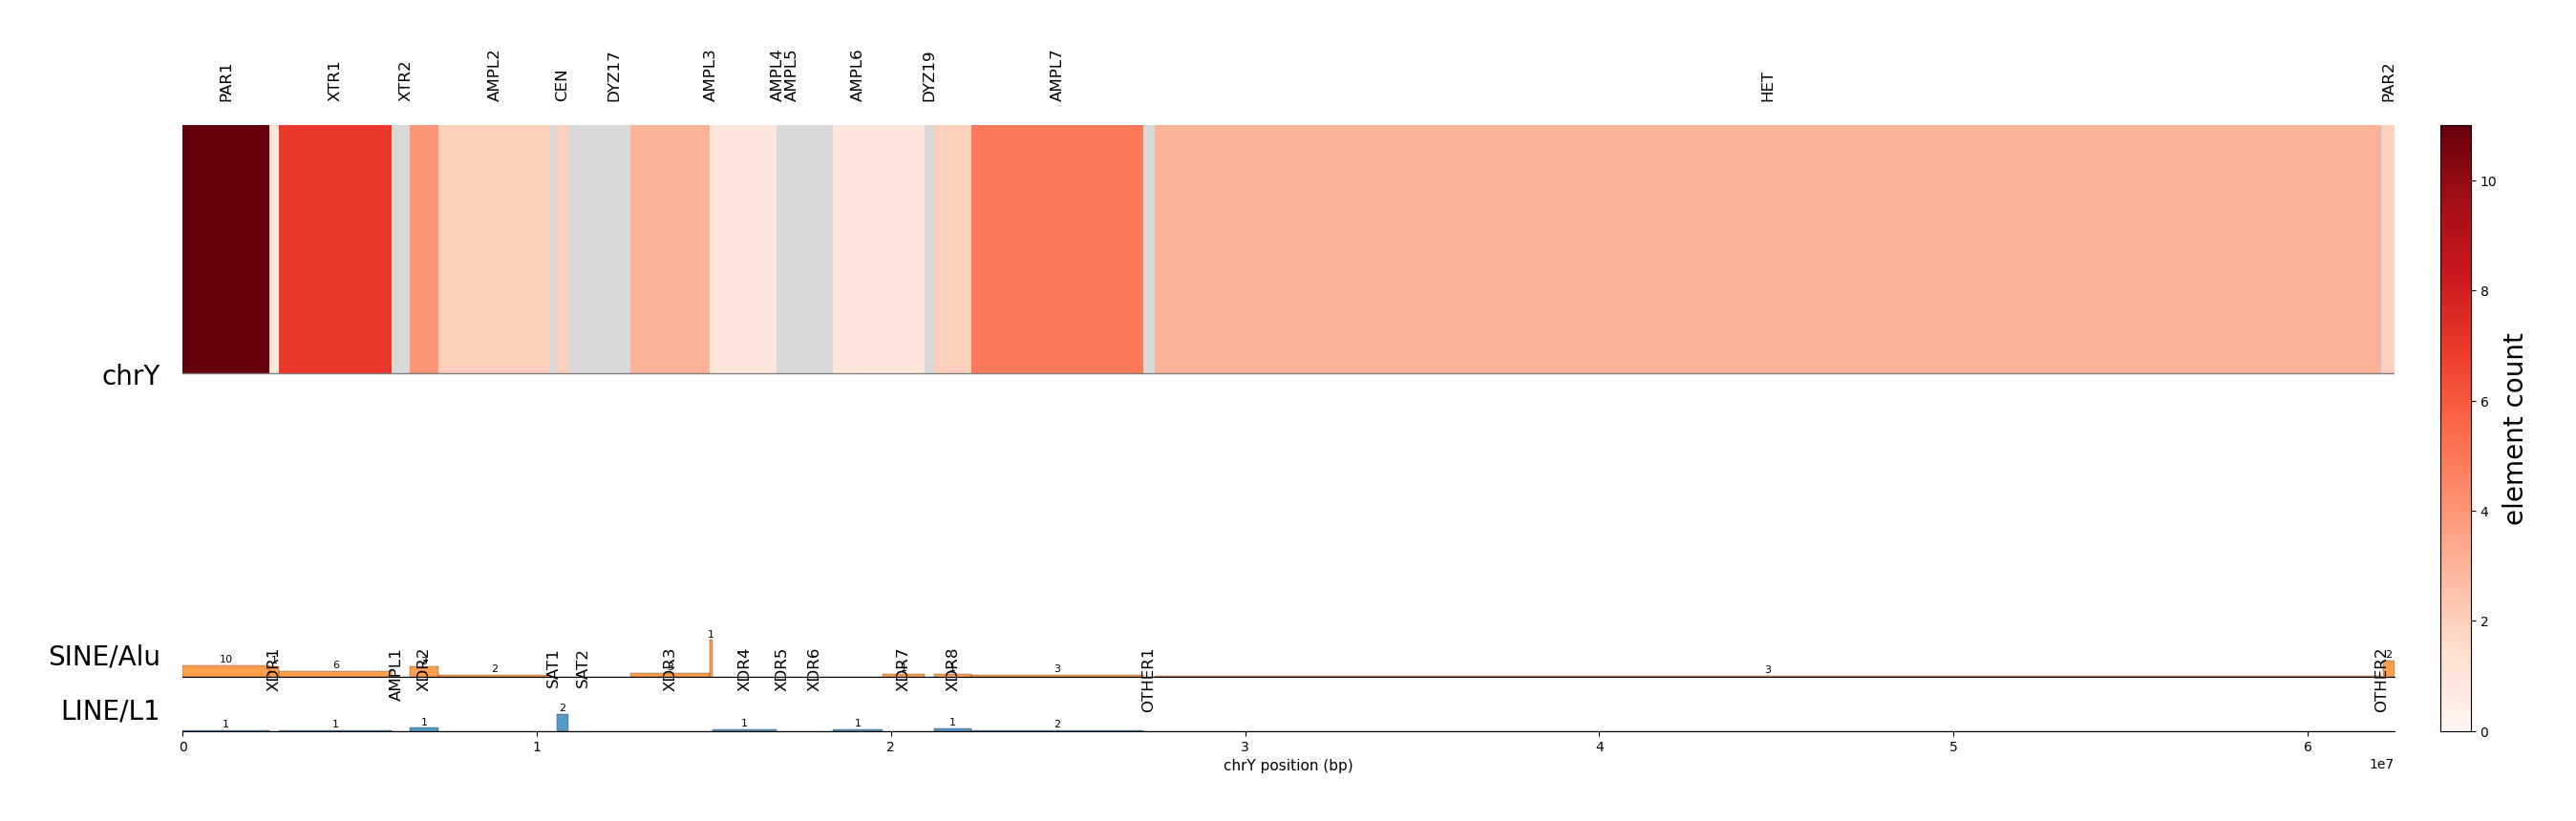

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
from pygenomeviz import GenomeViz

bed = hg38bed.copy()

required_cols = ["chr", "start", "end", "name", "seq_class"]
missing_cols = [c for c in required_cols if c not in bed.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in hg38bed: {missing_cols}")

bed["start"] = pd.to_numeric(bed["start"], errors="coerce")
bed["end"] = pd.to_numeric(bed["end"], errors="coerce")

bed = bed[bed["chr"] == "chrY"].copy()
bed = bed.dropna(subset=["start", "end"]).copy()
bed["start"] = bed["start"].astype(int)
bed["end"] = bed["end"].astype(int)
bed = bed.sort_values(["start", "end"]).reset_index(drop=True)
bed["region_length"] = bed["end"] - bed["start"]


valid_regions = set(bed["name"].dropna().astype(str))
filtered_hits = [x for x in uniqueHits if x in valid_regions]
region_counter = Counter(filtered_hits)

bed["element_count"] = bed["name"].map(region_counter).fillna(0).astype(int)
bed["element_density_per_mb"] = bed["element_count"] / (bed["region_length"] / 1_000_000)

value_col = "element_count"
use_log = False

if use_log:
    bed["plot_value"] = np.log10(bed[value_col] + 1)
    color_col = "plot_value"
    colorbar_label = f"log10({value_col} + 1)"
else:
    color_col = value_col
    colorbar_label = value_col.replace("_", " ")

vmin = bed[color_col].min()
vmax = bed[color_col].max()

if vmin == vmax:
    norm = mpl.colors.Normalize(vmin=0, vmax=max(1, vmax))
else:
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap = mpl.cm.Reds
bed["fill_color"] = [
    "#d9d9d9" if v == 0 else mpl.colors.to_hex(cmap(norm(v)))
    for v in bed[color_col]
]


region_dict = uniqueHitDict.copy()
keys_to_plot = list(region_dict.keys())

density_rows = []
for key in keys_to_plot:
    this_hits = [x for x in region_dict[key] if x in valid_regions]
    this_counter = Counter(this_hits)

    tmp = bed[["name", "start", "end", "region_length"]].copy()
    tmp["track_name"] = key
    tmp["count"] = tmp["name"].map(this_counter).fillna(0).astype(int)
    tmp["density_per_mb"] = tmp["count"] / (tmp["region_length"] / 1_000_000)
    density_rows.append(tmp)

density_df = pd.concat(density_rows, ignore_index=True)

# mini_value_col = "count"
mini_value_col = "density_per_mb"

chrY_len = int(bed["end"].max())

gv = GenomeViz(fig_width=24)
track = gv.add_feature_track("chrY", chrY_len)

good_name_set = set(goodNameList)

for _, row in bed.iterrows():
    start = int(row["start"])
    end = int(row["end"])
    fill_color = row["fill_color"]

    track.add_feature(
        start,
        end,
        strand=1,
        plotstyle="box",
        facecolor=fill_color,
        edgecolor="black",
        linewidth=1.0
    )

fig = gv.plotfig()
fig.set_size_inches(24, 2.8 + 1.2 * len(keys_to_plot))

main_ax = fig.axes[0]

y_top = 1.05
y_bottom = -0.05

label_rows = bed[bed["name"].isin(good_name_set)].copy()

for i, (_, row) in enumerate(label_rows.iterrows()):
    seqclass = str(row["name"])
    mid = (int(row["start"]) + int(row["end"])) / 2

    if i % 2 == 0:
        y = y_top
        va = "bottom"
    else:
        y = y_bottom
        va = "top"

    main_ax.text(
        mid,
        y,
        seqclass,
        ha="center",
        va=va,
        fontsize=12,
        rotation=90,
        transform=main_ax.get_xaxis_transform()
    )


main_pos = main_ax.get_position()

left = main_pos.x0
width = main_pos.width
main_bottom = main_pos.y0

track_height = 0.08
track_gap = 0.03

mini_max = density_df[mini_value_col].max()
if mini_max == 0:
    mini_max = 1

mini_axes = []

track_colors = {
    "LINE/L1": "#1f77b4",
    "SINE/Alu": "#ff7f0e",
    "Retroposon/SVA": "#2ca02c"
}

for i, key in enumerate(keys_to_plot):
    bottom = main_bottom - (i + 1) * (track_height + track_gap)

    ax_i = fig.add_axes([left, bottom, width, track_height], sharex=main_ax)
    mini_axes.append(ax_i)

    sub = density_df[density_df["track_name"] == key].copy()

    for _, row in sub.iterrows():
        x0 = int(row["start"])
        x1 = int(row["end"])
        val = float(row[mini_value_col])
        count_val = int(row["count"])

        height = val / mini_max if mini_max > 0 else 0

        rect = plt.Rectangle(
            (x0, 0),
            x1 - x0,
            height,
            facecolor=track_colors.get(key, "black"),
            edgecolor="#222222",
            linewidth=0.3,
            alpha=0.75
        )
        ax_i.add_patch(rect)

        if count_val > 0:
            mid = (x0 + x1) / 2

            text_y = min(max(height + 0.03, 0.06), 1.02)

            ax_i.text(
                mid,
                text_y,
                str(count_val),
                ha="center",
                va="bottom",
                fontsize=8,
                clip_on=False
            )

    ax_i.set_xlim(0, chrY_len)
    ax_i.set_ylim(0, 1.08)

    ax_i.spines["top"].set_visible(False)
    ax_i.spines["right"].set_visible(False)
    ax_i.spines["left"].set_visible(False)
    ax_i.set_yticks([])
    ax_i.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    ax_i.text(
        -0.01,
        0.5,
        key,
        ha="right",
        va="center",
        fontsize=20,
        transform=ax_i.transAxes
    )

if mini_axes:
    mini_axes[-1].tick_params(axis="x", which="both", bottom=True, labelbottom=True)
    mini_axes[-1].set_xlabel("chrY position (bp)", fontsize=11)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=[main_ax] + mini_axes, fraction=0.015, pad=0.02)
cbar.set_label(colorbar_label, fontsize=20)

fig.savefig("/chrY_element_density.pdf", bbox_inches="tight")
fig.savefig("/chrY_element_density.jpeg", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
sum(bed['element_count'])

46

In [22]:
len(set(nonFixedElements['MainElement']))

46

In [23]:
import re
from io import StringIO

import dendropy
import matplotlib as mpl
import matplotlib.pyplot as plt
from Bio import Phylo

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42


def reduce_haplogroup_one_level(hg):
    if hg is None:
        return None

    hg = str(hg).strip()
    if hg == "" or hg.lower() == "nan":
        return None

    hg = hg.replace(" ", "")

    m = re.match(r"^([A-Za-z]+)(\d+)?", hg)
    if not m:
        return hg

    letters = m.group(1).upper()
    digits = m.group(2)

    if digits is not None:
        return f"{letters}{digits}"
    else:
        return letters


def get_haplogroup_order_from_phylogeny(phylogeneticOrder, haplogroup_dict):
    ordered_groups = []
    seen = set()

    for sample in phylogeneticOrder:
        if sample not in haplogroup_dict:
            continue

        subgroup = reduce_haplogroup_one_level(haplogroup_dict[sample])
        if subgroup is None:
            continue

        if subgroup not in seen:
            seen.add(subgroup)
            ordered_groups.append(subgroup)

    return ordered_groups


def choose_representatives_from_phylogeny(tree, phylogeneticOrder, haplogroup_dict):
    tree_sample_names = {leaf.taxon.label for leaf in tree.leaf_node_iter()}
    representative_by_group = {}

    for sample in phylogeneticOrder:
        if sample not in tree_sample_names:
            continue
        if sample not in haplogroup_dict:
            continue

        subgroup = reduce_haplogroup_one_level(haplogroup_dict[sample])
        if subgroup is None:
            continue

        if subgroup not in representative_by_group:
            representative_by_group[subgroup] = sample

    return representative_by_group


def sort_biophylo_clade_by_order(clade, order_index):
    if clade.is_terminal():
        return order_index.get(clade.name, 10**9)

    child_scores = []
    for child in clade.clades:
        score = sort_biophylo_clade_by_order(child, order_index)
        child_scores.append((score, child))

    child_scores.sort(key=lambda x: x[0])
    clade.clades = [child for _, child in child_scores]

    return min(score for score, _ in child_scores)


def build_simplified_haplogroup_tree(
    nexus_file,
    haplogroup_dict,
    phylogeneticOrder,
    preserve_underscores=True,
):
    tree = dendropy.Tree.get(
        path=nexus_file,
        schema="nexus",
        preserve_underscores=preserve_underscores,
    )

    representative_by_group = choose_representatives_from_phylogeny(
        tree, phylogeneticOrder, haplogroup_dict
    )

    if len(representative_by_group) < 2:
        raise ValueError(
            "Fewer than two haplogroup subgroups were found in both the tree and haplogroup dictionary."
        )

    keep_samples = set(representative_by_group.values())

    taxa_to_keep = []
    for leaf in tree.leaf_node_iter():
        if leaf.taxon.label in keep_samples:
            taxa_to_keep.append(leaf.taxon)

    tree.retain_taxa(taxa_to_keep)

    try:
        tree.suppress_unifurcations()
    except Exception:
        pass

    sample_to_group = {sample: group for group, sample in representative_by_group.items()}

    for leaf in tree.leaf_node_iter():
        sample = leaf.taxon.label
        if sample in sample_to_group:
            leaf.taxon.label = sample_to_group[sample]

    newick_str = tree.as_string(schema="newick")
    bio_tree = Phylo.read(StringIO(newick_str), "newick")

    full_group_order = get_haplogroup_order_from_phylogeny(phylogeneticOrder, haplogroup_dict)
    present_groups = {term.name for term in bio_tree.get_terminals()}
    group_order = [g for g in full_group_order if g in present_groups]

    order_index = {g: i for i, g in enumerate(group_order)}
    sort_biophylo_clade_by_order(bio_tree.root, order_index)

    return bio_tree, representative_by_group, group_order


def plot_simplified_haplogroup_tree(
    bio_tree,
    figsize=(10, 6),
    title="Simplified Haplogroup Tree",
    show_branch_lengths=False,
    save_path=None,
    dpi=300,
):
    """
    Plot the simplified tree and optionally save it.
    """
    fig, ax = plt.subplots(figsize=figsize)

    if show_branch_lengths:
        Phylo.draw(
            bio_tree,
            axes=ax,
            do_show=False,
            branch_labels=lambda c: None if c.branch_length is None else round(c.branch_length, 4),
        )
    else:
        Phylo.draw(
            bio_tree,
            axes=ax,
            do_show=False,
        )

    ax.set_title(title)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    plt.close(fig)


def simplified_haplogroup_tree_workflow(
    nexus_file,
    haplogroup_dict,
    phylogeneticOrder,
    figsize=(10, 6),
    title="Simplified Haplogroup Tree",
    show_branch_lengths=False,
    save_path=None,
    dpi=300,
):
    bio_tree, representative_by_group, group_order = build_simplified_haplogroup_tree(
        nexus_file=nexus_file,
        haplogroup_dict=haplogroup_dict,
        phylogeneticOrder=phylogeneticOrder,
    )

    plot_simplified_haplogroup_tree(
        bio_tree,
        figsize=figsize,
        title=title,
        show_branch_lengths=show_branch_lengths,
        save_path=save_path,
        dpi=dpi,
    )

    return bio_tree, representative_by_group, group_order

In [33]:
plotDF=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/MEIs/inSituCalled_Polymorphic_MEI_FrozenCallElements.03262026.csv').set_index("element_id")
elementPlacement=[]
for element in set(nonFixedElements['MainElement']):
    elementPlacement.append([plotDF.at[element,'deepest_shared_haplogroup_branch'], plotDF.at[element,'Element_Designation'],plotDF.at[element,'n_carriers']])

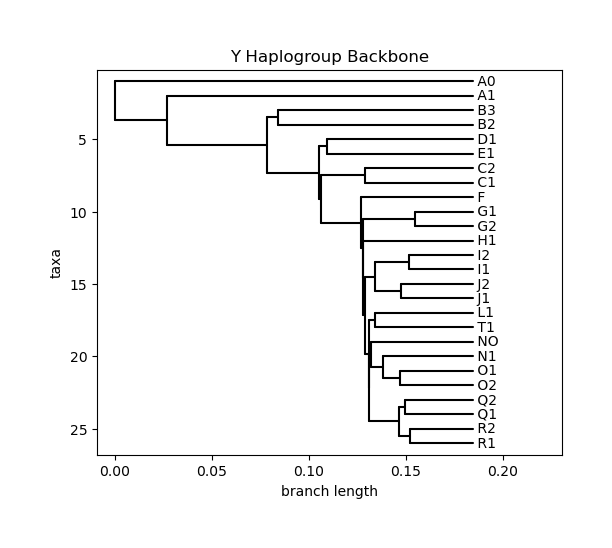

In [25]:
bio_tree, representative_by_group, group_order = simplified_haplogroup_tree_workflow(
    nexus_file="/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex",
    haplogroup_dict=haplogroups,
    phylogeneticOrder=phylogeneticOrder,
    figsize=(6, 5),
    title="Y Haplogroup Backbone",
    save_path="/Y_haplogroup_backbone.pdf",
    dpi=300,
)

In [26]:
plotDF['Sample_Coordinates']=[list(nonFixedElements[nonFixedElements['MainElement']==x].index) for x in plotDF.index]

In [27]:
plotDF['Sequence_Class']=[set(nonFixedElements[nonFixedElements['MainElement']==x]['overlap_name_string']) for x in plotDF.index]

In [28]:
plotDF[['n_carriers', 'carrier_samples', 'carrier_haplogroups',
       'deepest_shared_haplogroup_branch',
       'inferred_insertion_haplogroup', 'span_size','first_sample', 'last_sample', 'Age',
       'Element_Designation', 'Sample_Coordinates','Sequence_Class']].to_csv("/MEI_Callset_Frozen.03292026.csv")
                                                                    

In [35]:
df = pd.DataFrame(elementPlacement, columns=['group', 'element', 'n_carriers'])
df['group2'] = df['group'].apply(lambda x: x if '|' in x else x[:2])

# Count totals per group and element type
summary = (
    df.groupby(['group2', 'element'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

print(summary)

element                         group2  LINE/L1  SINE/Alu
0                                   A0        2         1
1                                   A1        0         2
2                                  A|B        0         1
3                                  A|E        0         1
4                                   B2        0         1
5        B|C|D|E|F|G|H|I|J|L|N|O|Q|R|T        1         0
6              B|D|E|G|H|I|J|N|O|Q|R|T        0         1
7                                   C1        0         2
8                                   C2        1         0
9                C|D|E|F|H|J|L|N|O|Q|R        0         1
10                                  D1        0         2
11                       D|E|G|J|O|Q|R        0         1
12                           D|E|O|Q|R        1         0
13                                  E1        0         8
14                                 E|R        0         1
15                                   G        0         1
16            